Purpose: Re-make figure 2B-C (stacked bar plots of CAM gene ASE by treatment) with genes of particular interest from David's paper and from HybridExpress & maSigPro results. Put remaining CAM genes into a supplemental figure.<br>
Author: Anna Pardo<br>
Date initiated: Apr. 24, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from matplotlib.colors import LinearSegmentedColormap

In [2]:
asecam = pd.read_csv("./ASE_gttreat_CAMresults.txt",sep="\t",header="infer")
asecam.head()

,GeneID,syntelogID,genotype,treat,subgenome,gene_abbr_unique,gene_abbr,Pathway,syntelog_name,CAMphys
0,Yucal.02G133400.v2.1,recip_syn3801,18,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
1,Yucal.02G133400.v2.1,recip_syn3801,2AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
2,Yucal.02G133400.v2.1,recip_syn3801,2AB,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
3,Yucal.02G133400.v2.1,recip_syn3801,1AB,W,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM
4,Yucal.02G133400.v2.1,recip_syn3801,18,D,Ya,Ya_NADP-ME_2,NADP-ME,CAM-light,NADP-ME_2,C3+CAM


In [3]:
# load updated CAM annotation
camv3 = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                   sep="\t",header="infer")
camv3.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [4]:
v2cam = pd.read_csv("/home/leviathan22/Yucca_genomics/Yucca_genes_of_interest.csv",sep=",",header="infer",usecols=[
    "Pathway","gene_abbr","YA_genes","YF_genes","YA_proteins_cycle**","YF_proteins_cycle**"
])
v2cam.head()

,Pathway,gene_abbr,YA_genes,YF_genes,YA_proteins_cycle**,YF_proteins_cycle**
0,CA-cycle,OGDH-E1,NaN,YucfiPri.12G021500.1,N,Y
1,CA-cycle,OGDH-E1,Yucal.01G311700.1,YucfiPri.01G344400.1,N,N
2,CA-cycle,OGDH-E1,Yucal.02G046600.1,YucfiPri.02G049800.1,Y,N
3,CA-cycle,OGDH-E1,Yucal.02G234000.1,YucfiPri.02G257600.1,Y,Y
4,CA-cycle,OGDH-E2,Yucal.04G221700.1,YucfiPri.04G249300.1,Y,N


In [5]:
v2cam = v2cam[v2cam["Pathway"].isin(["CAM-dark","CAM-light"])]

In [6]:
v2cam.head()

,Pathway,gene_abbr,YA_genes,YF_genes,YA_proteins_cycle**,YF_proteins_cycle**
44,CAM-dark,bCA1234,NaN,YucfiPri.06G182000.1,N,Y
45,CAM-dark,bCA5,NaN,YucfiPri.21G092200.1,N,N
46,CAM-dark,bCA1234,Yucal.01G165600.1,YucfiPri.01G182600.1,N,N
47,CAM-dark,bCA1234,Yucal.02G112700.1,YucfiPri.02G120100.1,N,Y
48,CAM-dark,bCA5,Yucal.04G001000.1,YucfiPri.04G001100.1,N,N


In [7]:
# gene ID lists from Fig 3 Wickell et al. 2026
yaint = ["Yucal.02G112700","Yucal.06G042800","Yucal.07G108300","Yucal.16G056000","Yucal.06G106600","Yucal.12G110500",
        "Yucal.05G072500"]
yfint = ["YucfiPri.02G120100.1","YucfiPri.06G048800.1","YucfiPri.07G119600.1","YucfiPri.16G064900.1","YucfiPri.06G117400.1",
        "YucfiPri.12G153000.1","YucfiPri.05G086800.1"]

In [8]:
ya_v2yf = list(v2cam[v2cam["YF_genes"].isin(yfint)]["YA_genes"])

In [9]:
ya2 = []
for i in ya_v2yf:
    ya2.append(i.rstrip(".1"))

In [10]:
len(set(ya2).intersection(set(yaint)))

6

In [11]:
set(ya2).difference(set(yaint))

{'Yucal.12G110300'}

In [12]:
set(yaint).difference(set(ya2))

{'Yucal.12G110500'}

In [13]:
v2cam[v2cam["YF_genes"].isin(yfint)]

,Pathway,gene_abbr,YA_genes,YF_genes,YA_proteins_cycle**,YF_proteins_cycle**
47,CAM-dark,bCA1234,Yucal.02G112700.1,YucfiPri.02G120100.1,N,Y
56,CAM-dark,NAD-MDH-ct,Yucal.16G056000.1,YucfiPri.16G064900.1,N,Y
59,CAM-dark,BPPC,Yucal.07G108300.1,YucfiPri.07G119600.1,Y,N
63,CAM-dark,PPPC,Yucal.06G042800.1,YucfiPri.06G048800.1,N,Y
68,CAM-dark,PPCK,Yucal.05G072500.1,YucfiPri.05G086800.1,N,N
80,CAM-light,NADP-ME,Yucal.06G106600.1,YucfiPri.06G117400.1,Y,Y
83,CAM-light,PPDK,Yucal.12G110300.1,YucfiPri.12G153000.1,N,N


In [15]:
# load syntelogs between Yf v2 & v3
allsyn = pd.read_csv("../YfV2.Yfilamentosa.i1.blocks",sep="\t",header=None)
allsyn.head()

,0,1
0,YucfiPri.01G000100.1,.
1,YucfiPri.01G000200.1,YufilH1000001m
2,YucfiPri.01G000300.1,YufilH1000002m
3,YucfiPri.01G000300.2,YufilH1000002m
4,YucfiPri.01G000300.3,YufilH1000002m


In [17]:
intsyn = allsyn[allsyn[0].isin(yfint)]

In [18]:
yfint_v3 = list(intsyn[1])

In [20]:
yfint_v3

['YufilH1011201m',
 'YufilH1032169m',
 'YufilH1038083m',
 'YufilH1039537m',
 'YufilH1044442m',
 'YufilH1062820m',
 'YufilH1072277m']

In [21]:
asecam.tail()

,GeneID,syntelogID,genotype,treat,subgenome,gene_abbr_unique,gene_abbr,Pathway,syntelog_name,CAMphys
770,YufilH1086337m.g,recip_syn29627,43,W,Yf,Yf_PEPCK,PEPCK,CAM-light,PEPCK_2/1,CAM
771,YufilH1086337m.g,recip_syn29627,53,W,Yf,Yf_PEPCK,PEPCK,CAM-light,PEPCK_2/1,CAM
772,YufilH1086337m.g,recip_syn29627,48,W,Yf,Yf_PEPCK,PEPCK,CAM-light,PEPCK_2/1,C3+CAM
773,YufilH1003887m.g,recip_syn1434,18,D,Yf,Yf_bCA1234_2,bCA1234,CAM-dark,bCA1234_1/2,C3+CAM
774,YufilH1062820m.g,recip_syn21197,13,W,Yf,Yf_PPDK_1,PPDK,CAM-light,PPDK_1,facultative CAM


In [22]:
yfi = []
for i in yfint_v3:
    yfi.append(i+".g")

In [25]:
asecam[asecam["GeneID"].isin(yfi)]

,GeneID,syntelogID,genotype,treat,subgenome,gene_abbr_unique,gene_abbr,Pathway,syntelog_name,CAMphys
532,YufilH1011201m.g,recip_syn3628,18,W,Yf,Yf_bCA1234_3,bCA1234,CAM-dark,bCA1234_2/3,C3+CAM
533,YufilH1011201m.g,recip_syn3628,2AB,W,Yf,Yf_bCA1234_3,bCA1234,CAM-dark,bCA1234_2/3,C3+CAM
534,YufilH1011201m.g,recip_syn3628,2AB,D,Yf,Yf_bCA1234_3,bCA1234,CAM-dark,bCA1234_2/3,C3+CAM
535,YufilH1011201m.g,recip_syn3628,1AB,W,Yf,Yf_bCA1234_3,bCA1234,CAM-dark,bCA1234_2/3,C3+CAM
536,YufilH1011201m.g,recip_syn3628,18,D,Yf,Yf_bCA1234_3,bCA1234,CAM-dark,bCA1234_2/3,C3+CAM
...,...,...,...,...,...,...,...,...,...,...
730,YufilH1044442m.g,recip_syn14735,13,W,Yf,Yf_BPPC,BPPC,CAM-dark,BPPC_1,facultative CAM
731,YufilH1044442m.g,recip_syn14735,45,W,Yf,Yf_BPPC,BPPC,CAM-dark,BPPC_1,C3+CAM
732,YufilH1044442m.g,recip_syn14735,45,D,Yf,Yf_BPPC,BPPC,CAM-dark,BPPC_1,C3+CAM
733,YufilH1044442m.g,recip_syn14735,52,D,Yf,Yf_BPPC,BPPC,CAM-dark,BPPC_1,CAM


In [26]:
yaint

['Yucal.02G112700',
 'Yucal.06G042800',
 'Yucal.07G108300',
 'Yucal.16G056000',
 'Yucal.06G106600',
 'Yucal.12G110500',
 'Yucal.05G072500']

In [28]:
yai = [i+".v2.1" for i in yaint]

In [37]:
# relate this to syntelog IDs - Ya to Yf V3
# load syntelog info
syn = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf.txt",sep="\t",header="infer")
syn.head()

,Yf_GeneID,Ya_GeneID,syntelogID
0,YufilH1000002m.g,Yucal.01G000100.v2.1,recip_syn1
1,YufilH1000007m.g,Yucal.01G000200.v2.1,recip_syn2
2,YufilH1000011m.g,Yucal.01G000400.v2.1,recip_syn3
3,YufilH1000013m.g,Yucal.01G000500.v2.1,recip_syn4
4,YufilH1000018m.g,Yucal.01G000600.v2.1,recip_syn5


In [41]:
synya = syn[syn["Ya_GeneID"].isin(yai)]
synyf = syn[syn["Yf_GeneID"].isin(yfi)]

In [42]:
synint = list(synya["syntelogID"])+list(synyf["syntelogID"])

In [45]:
synint = list(set(synint))

In [46]:
camint = asecam[asecam["syntelogID"].isin(synint)]

In [48]:
camsupp = asecam[~asecam["syntelogID"].isin(synint)]

In [49]:
len(camint["GeneID"].unique())

8

In [50]:
len(camsupp["GeneID"].unique())

25

In [34]:
camint["GeneID"].unique()

array(['Yucal.06G042800.v2.1', 'Yucal.06G106600.v2.1',
       'Yucal.07G108300.v2.1', 'Yucal.16G056000.v2.1', 'YufilH1011201m.g',
       'YufilH1032169m.g', 'YufilH1044442m.g', 'YufilH1062820m.g'],
      dtype=object)

In [51]:
camint["gene_abbr_unique"].unique()

array(['Ya_PPPC_2', 'Ya_NADP-ME_3', 'Ya_BPPC_1', 'Ya_NAD-MDH-ct_3',
       'Yf_bCA1234_3', 'Yf_PPCK_2', 'Yf_BPPC', 'Yf_PPDK_1'], dtype=object)

In [36]:
camint.columns

Index(['GeneID', 'syntelogID', 'genotype', 'treat', 'subgenome',
       'gene_abbr_unique', 'gene_abbr', 'Pathway', 'syntelog_name', 'CAMphys'],
      dtype='object')

In [55]:
len(camint["syntelog_name"].unique())

7

In [53]:
custompal = {
    "Ya_C3+CAM":"skyblue",
    "Ya_CAM":"navy",
    "Ya_facultative CAM":"royalblue",
    "Yf_C3+CAM":"coral",
    "Yf_CAM":"saddlebrown",
    "Yf_facultative CAM":"orangered"
}

In [52]:
# create a function to format the data for a given treatment
def plotdata(t,data):
    subdf = data[data["treat"]==t]
    subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]
    wide = pd.pivot(subdf,index="syntelog_name", columns='sgphys', values='count')
    wide.fillna(0,inplace=True)
    return wide

In [57]:
def plot_ase_counts(df,fname,savedir="./",palette=custompal):
    asecounts = df.groupby(["syntelog_name","subgenome","CAMphys","treat"]).count()[["GeneID"]].reset_index().rename(columns={"GeneID":"count"})
    wplot = plotdata("W",asecounts)
    dplot = plotdata("D",asecounts)
    # make sure both plot dataframes have all the same IDs
    if len(set(list(wplot.index)).difference(set(list(dplot.index))))>0:
        wdiff = list(set(list(wplot.index)).difference(set(list(dplot.index))))
        dplot = dplot.reset_index()
        add = {"syntelog_name":wdiff}
        for c in dplot.columns:
            if "syntelog" not in c:
                add[c] = [0]*len(wdiff)
        add_df = pd.DataFrame(add)
        dplot = pd.concat([dplot,add_df])
        dplot.set_index("syntelog_name",inplace=True)
    if len(set(list(dplot.index)).difference(set(list(wplot.index))))>0:
        ddiff = list(set(list(dplot.index)).difference(set(list(wplot.index))))
        wplot = wplot.reset_index()
        add = {"syntelog_name":ddiff}
        for c in wplot.columns:
            if "syntelog" not in c:
                add[c] = [0]*len(ddiff)
        add_df = pd.DataFrame(add)
        wplot = pd.concat([wplot,add_df])
        wplot.set_index("syntelog_name",inplace=True)
    
    # do plotting
    sns.set_theme(style="whitegrid")
    fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(14,10),sharey=True,sharex=True)
    wplot.plot(kind="barh",ax=ax[0],stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(palette.values())))
    ax[0].get_legend().remove()
    # customize axis labels
    ax[0].tick_params(which="both",labelsize=14)
    ax[0].set_ylabel("")
    ax[0].set_xlabel("Number of genotypes",fontsize=14)
    plt.xticks(ticks=range(0,21,2))
    ax[0].set_title("CAM ASE in watered",fontsize=20)

    dplot.plot(kind="barh",ax=ax[1],stacked=True,colormap=LinearSegmentedColormap.from_list("custom",list(palette.values())))

    # move legend outside plot & customize
    plt.legend(bbox_to_anchor=(1,1),labels=["Ya, C3+CAM","Ya, CAM","Ya, facultative CAM",
                                           "Yf, C3+CAM","Yf, CAM","Yf, facultative CAM"],
              fontsize=12)
    ax[1].tick_params(which="both",labelsize=14)
    ax[1].set_xlabel("Number of genotypes",fontsize=14)
    ax[1].set_title("CAM ASE in drought",fontsize=20)
    fig.tight_layout()
    plt.savefig(os.path.join(savedir,fname+".png"),dpi=200,bbox_inches="tight")
    plt.savefig(os.path.join(savedir,fname+".svg"),dpi=200,bbox_inches="tight")
    plt.savefig(os.path.join(savedir,fname+".pdf"),dpi=200,bbox_inches="tight")
        

/tmp/ipykernel_207/2746876364.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]
/tmp/ipykernel_207/2746876364.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]


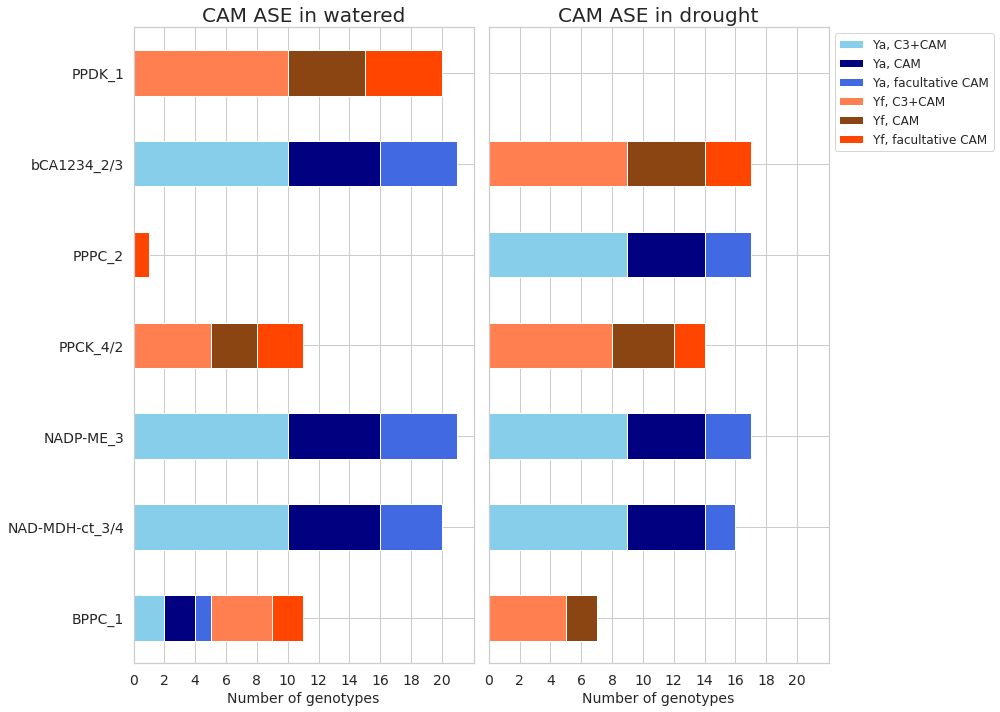

In [58]:
plot_ase_counts(camint,"camgene_ase_counts_Wickellgenes")

/tmp/ipykernel_207/2746876364.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]
/tmp/ipykernel_207/2746876364.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf["sgphys"] = subdf["subgenome"]+"_"+subdf["CAMphys"]


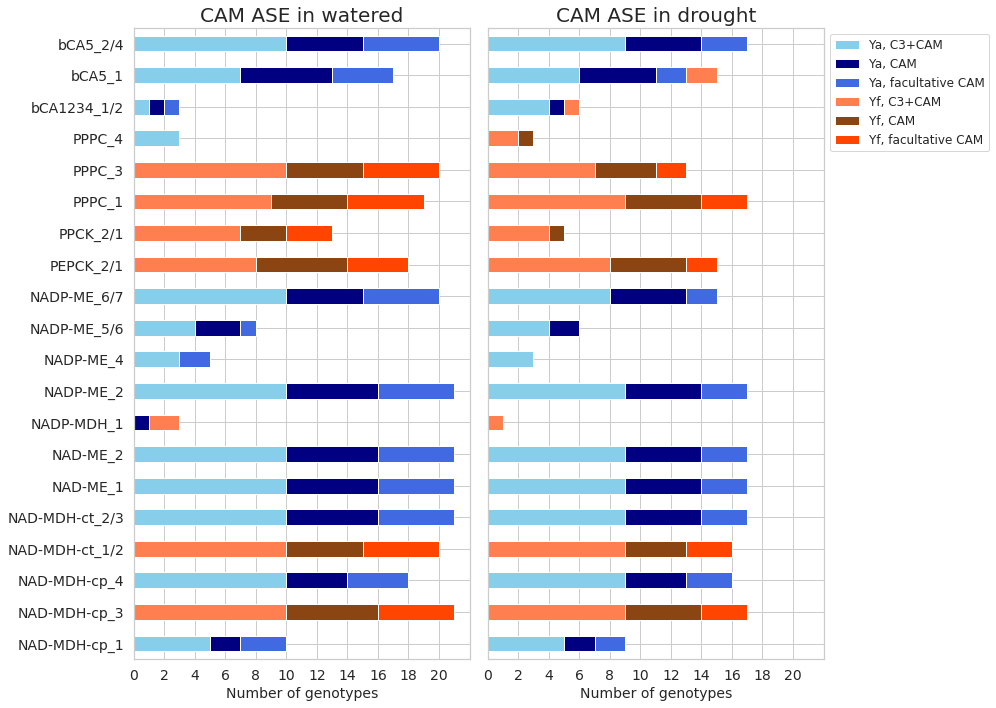

In [59]:
plot_ase_counts(camsupp,"suppfig_camgenes_asecounts")